In [1]:
import numpy as np
import scipy.signal as scs
import matplotlib.pyplot as plt

Counting the neighbours of a cell can be seen as doing a 2D discrete convolution operation of a grid 3x3 with all 1s on the edges (neighbours) and a 0 in the middle (selected cell) on the world grid. This is indeed the definition of convolution where each element of the moving grid is multiplied by the value assigned to the tile of the major grid it passing onto, and then they are all summed to get the value of the convolution (in this case the number of neighbours since the grids have as values zero and one). At the end we obtain a new matrix which has as entries the number of neighbours for each cell.

In [2]:
def evolution(world, neighbours):
    new_world = np.zeros_like(world)
    # condition1 = ( neighbours < 2 ) useless, we start from a 0's new world ——> dead
    # condition2 = ( neighbours > 3 ) ——> dead
    # condition3 = ( neighbours == 2 ) | ( neighbours == 3 ) # '|' is bitwise 'or' ——> alive only if already alive
    # condition4 = ( neighbours == 3 ) ——> become alive if dead
    survive = ( world == 1 ) & ( neighbours == 2 ) # does not need the 3 ——> always alive
    born = ( neighbours == 3 )
    
    new_world[survive | born] = 1

    return new_world

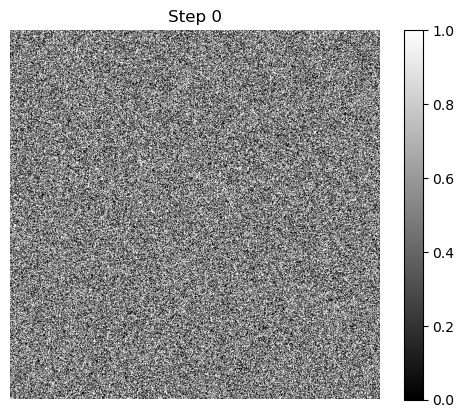

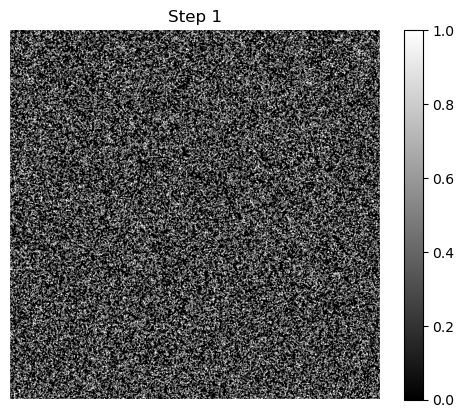

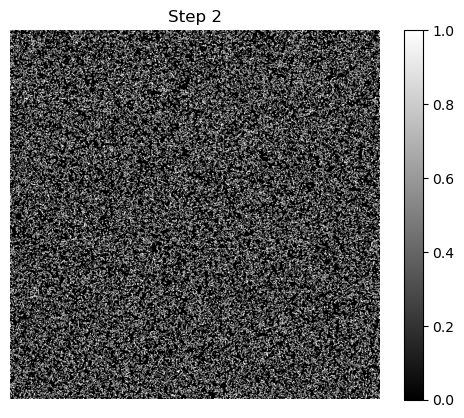

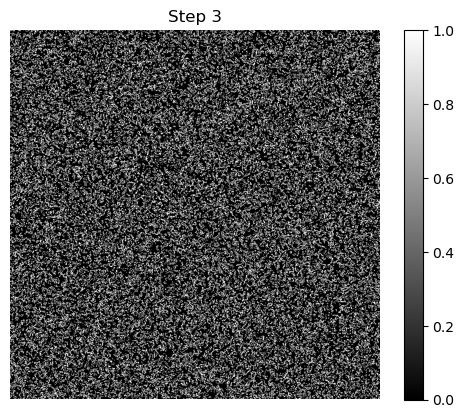

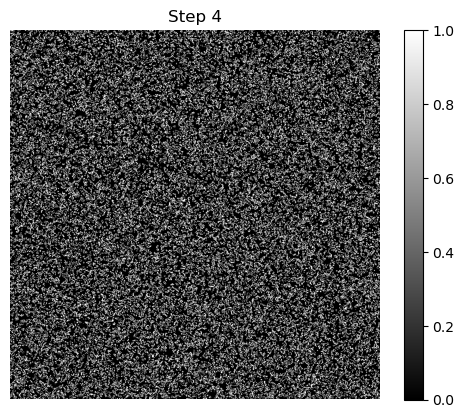

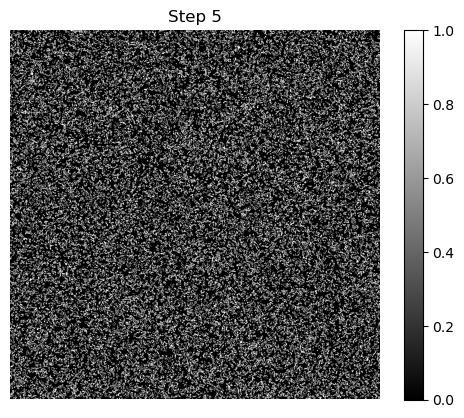

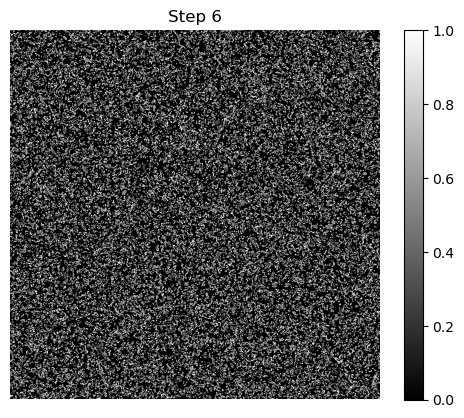

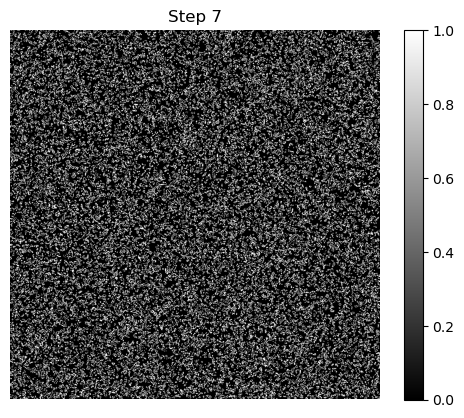

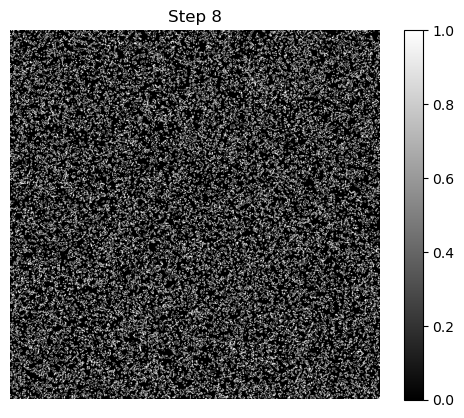

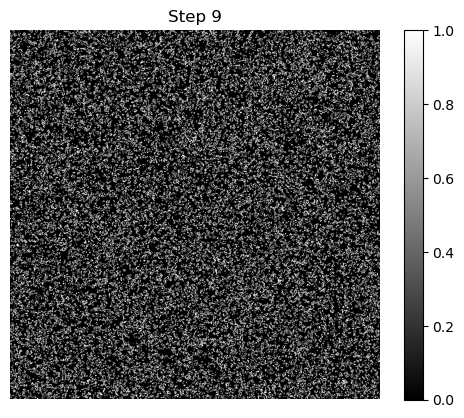

In [4]:
# Size of the world
N = 800
# Initialize the world at random
world = np.random.randint(0,2, size=(N,N))
# Create the mask for convolution
kernel = np.ones(shape=(3,3))
kernel[1,1] = 0 # Central value does not count in the convolution

# Temporary cycle
T = 10
for t in range(T):
    plt.clf()
    plt.imshow(world, cmap='gray')
    plt.colorbar()
    plt.title(f"Step {t}")
    plt.axis('off')
    plt.pause(0.3)
    
    # mode = 'same' gives a matrix of the same size of initial_world (centered)
    # default padding of the edges
    # default value 0 to fill pad input arrays with
    convolution = scs.convolve2d(world, kernel, mode='same')
    world = evolution(world, convolution)
    # print(new_world)

plt.show()